# Comparación de modelos

Comparamos los cuatro modelos entrenados sobre el mismo split (submuestra de 600 imágenes/clase, 64x64, mismo `train`/`val`/`test`):

- **Random Forest** (`randomForest.ipynb`)
- **CNN simple** (`cnn_simple.ipynb`)
- **CNN profunda** (`cnn_profunda.ipynb`)
- **Red neuronal simple / fully-connected** (`redesNeuronalesSimple.ipynb`)

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

resultados = {
    "Random Forest": 0.9655,
    "CNN simple": 0.9644,
    "CNN profunda": 0.9866,
    "Red simple (fully-connected)": 0.1169,
}

df_comparacion = pd.DataFrame({
    "modelo": list(resultados.keys()),
    "accuracy_test": list(resultados.values()),
})
df_comparacion

,modelo,accuracy_test
0,Random Forest,0.9655
1,CNN simple,0.9644
2,CNN profunda,0.9866
3,Red simple (fully-connected),0.1169


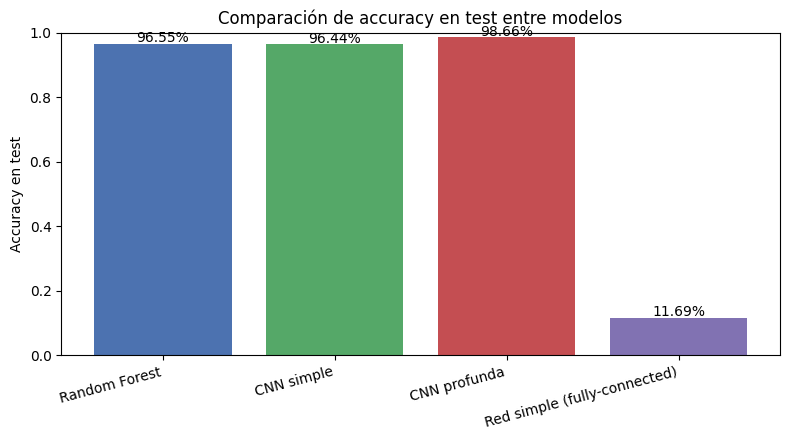

In [8]:
df_plot = df_comparacion.dropna()

plt.figure(figsize=(8, 4.5))
colores = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]
barras = plt.bar(df_plot["modelo"], df_plot["accuracy_test"], color=colores[:len(df_plot)])

for barra, valor in zip(barras, df_plot["accuracy_test"]):
    plt.text(barra.get_x() + barra.get_width() / 2, valor + 0.005, f"{valor:.2%}",
             ha="center", fontsize=10)

plt.ylim(0, 1.0)
plt.ylabel("Accuracy en test")
plt.title("Comparación de accuracy en test entre modelos")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## Discusión

**La CNN profunda es el mejor modelo** con 98.66% de accuracy en test, por encima de Random Forest (96.55%) y la CNN simple (96.44%), que quedan prácticamente empatados entre sí (0.11 puntos de diferencia, dentro del ruido esperado entre dos algoritmos tan distintos).

**¿Por qué gana la CNN profunda?** Tiene más capacidad (4 bloques de convolución con 32 a 256 filtros, batch normalization) para capturar detalles finos de la forma de la mano que distinguen letras parecidas. En su reporte de clasificación, los únicos puntos débiles son D, O y R (recall ~0.93-0.96), muy por encima del peor caso de la CNN simple (U con recall 0.93 y precisión 0.84) o de Random Forest (E y W con recall 0.88).

**Random Forest vs. CNN simple**: terminan casi empatados en accuracy, pero por caminos distintos. Random Forest ni siquiera ve la imagen como imagen, ya que trabaja con los píxeles aplanados en un solo vector, y aun así alcanza a una CNN. Esto sugiere que con esta cantidad de datos (17,400 imágenes) y esta resolución (64x64) ambos modelos ya están cerca del máximo que pueden dar, y que hace falta más capacidad, como la de la CNN profunda, para seguir mejorando.

**Costo de esa mejora**: la CNN profunda también fue la más lenta de entrenar, con unos 16 a 18 segundos por época contra apenas 4 segundos de la CNN simple. 

**Red simple (fully-connected) vs. el resto**: con 11.69% de accuracy en test, la red FC queda muy por debajo de los otros tres modelos (96-99%), aunque es más de 3 veces mejor que adivinar al azar (1/29 ≈ 3.45%). La causa principal es estructural: al aplanar cada imagen a un vector de 12,288 valores antes de la primera capa, el modelo pierde toda la información de vecindad espacial entre píxeles, que es justamente la señal que le permite a una CNN reconocer bordes y la forma general de la mano. Con 6.36 millones de parámetros — más que cualquiera de las CNNs — la red FC tiene mucha capacidad "en papel" pero la aprovecha de forma mucho menos eficiente, porque cada píxel se procesa de forma independiente en la primera capa en vez de explotar patrones locales reutilizables como hace una convolución.

**Random Forest vs. red FC**: es un contraste interesante — Random Forest también recibe los píxeles aplanados, sin ninguna noción de estructura espacial, y aun así llega a 96.55%, muy por encima del 11.69% de la red FC. Esto sugiere que la brecha no es solo "aplanar pierde información": el ensamble de árboles logra explotar patrones en los píxeles crudos de una forma mucho más efectiva que esta arquitectura de red FC con esta cantidad de datos.

**Selección para el resto del laboratorio**: el orden de efectividad queda CNN profunda (98.66%) > Random Forest (96.55%) ≈ CNN simple (96.44%) >> Red FC (11.69%). Con estos resultados, la **CNN profunda** es la candidata natural para el ejercicio 8 (pruebas con fotos propias) y para las conclusiones del ejercicio 9 (accesibilidad), al ser el modelo más acertado del grupo.